This notebook will test several model to for the recodification cno to ciuo problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk


def get_digits(df_col, n_digits, from_left=True):
	assert n_digits > 0, "n_digits must be a positive integer"
	assert n_digits < 5, "n_digits must be less than 5"
	if from_left:
		return (df_col // (10 ** (4 - n_digits))) % (10**n_digits)
	else:
		return df_col % (10**n_digits)

In [2]:
df = pd.read_csv("../data/processed/enes_2019.csv")
df["v183ciuo"] = df["v183ciuo"] - 10000
df = df.set_index(["nocues", "nhog", "miembro"])
print(df.shape)
df_aux = df.copy()
df_aux.head()

(15556, 154)


f_calib3  region  aglo  t_aglo  estrato_U  cod_U  age  \
nocues nhog miembro                                                          
1.0    1.0  1.0         778.0     3.0   6.0     4.0      164.0  682.0   56   
            2.0         778.0     3.0   6.0     4.0      164.0  682.0   51   
            3.0         778.0     3.0   6.0     4.0      164.0  682.0   31   
            4.0         778.0     3.0   6.0     4.0      164.0  682.0   31   
2.0    1.0  1.0         485.0     3.0   6.0     4.0      164.0  682.0   21   

                     sex_id  v110  v111  ...  v215b  v215bi  v216a  v216b  \
nocues nhog miembro                      ...                                
1.0    1.0  1.0           1   2.0   1.0  ...    NaN     0.0    0.0    NaN   
            2.0           2  10.0   2.0  ...    NaN     0.0    0.0    NaN   
            3.0           2   4.0   3.0  ...    NaN     0.0    0.0    NaN   
            4.0           1   2.0   5.0  ...    NaN     0.0    0.0    NaN   
2.0    1.0  1.0           2   2.0   1.0  ...    NaN     0.0    0.0    NaN   

                     v216bi  v217a  v217b  v217bi  total_income  ITI_d  
nocues nhog miembro                                                     
1.0    1.0  1.0         0.0    0.0    NaN     0.0        4500.0    6.0  
            2.0         0.0    0.0    NaN     0.0        4000.0    5.0  
            3.0         0.0    0.0    NaN     0.0           NaN    NaN  
            4.0         0.0    0.0    NaN     0.0           NaN    NaN  
2.0    1.0  1.0         0.0    0.0    NaN     0.0        6000.0    7.0  

[5 rows x 154 columns]

In [7]:
nodelist_cno_df = pd.read_csv("../data/raw/nodelist_cno.csv")
nodelist_cno_df["v183ciuo_first_1digits"] = nodelist_cno_df[
	"v183ciuo_first_1digits"
].astype(int, errors="ignore")
nodelist_cno_df["v183ciuo_first_2digits"] = nodelist_cno_df[
	"v183ciuo_first_2digits"
].astype(int, errors="ignore")
nodelist_cno_df.head()

,v183cno,cnolabel,v183ciuo_first_2digits,v183ciuo_first_1digits
0,49311,Trabajadores sin operación de maquinarias de l...,1.0,NaN
1,49331,Operadores de sistemas y/o equipos informatiza...,1.0,NaN
2,49312,Trabajadores sin operación de maquinarias de l...,2.0,NaN
3,49322,Operadores de maquinaria y/o equipos electrome...,2.0,NaN
4,49332,Operadores de sistemas y/o equipos informatiza...,2.0,NaN


There is 14536 valid cno values in the enes data vs 15556

In [8]:
# df = pd.merge(df, nodelist_cno_df, how="left", on="v183cno")
# df["v183ciuo_reconstructed"] = df["v183ciuo_first_2digits"] * 100 + df["v183ciuo_last_2digits"]

,v213bi,v214bi,v116,v148,v152a,CSO,v190,v114,v149a,v147a,...,v142,v141,v140,v139,v171,v134a,nocues,cnolabel,v183ciuo_first_2digits,v183ciuo_first_1digits
0,4500.0,0.0,2.0,3.0,1.0,4.0,6.0,1.0,1.0,6.0,...,4,2,1,1,1,1,1.0,Jefes de la construcción edilicia y de obras d...,31.0,NaN
1,4000.0,0.0,2.0,3.0,1.0,4.0,6.0,1.0,2.0,6.0,...,4,2,1,1,1,1,1.0,Trabajadores sin operación de maquinarias de l...,23.0,NaN
2,0.0,0.0,2.0,3.0,1.0,6.0,5.0,1.0,1.0,6.0,...,4,1,2,2,2,7,1.0,Vendedores y trabajadores sin operación de maq...,52.0,NaN
3,0.0,0.0,2.0,3.0,1.0,8.0,5.0,1.0,1.0,6.0,...,4,1,2,2,2,7,1.0,Trabajadores sin operación de maquinarias de l...,81.0,NaN
4,6000.0,0.0,1.0,3.0,1.0,6.0,5.0,2.0,1.0,6.0,...,4,2,2,1,1,1,2.0,Vendedores y trabajadores sin operación de maq...,52.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15551,25353.0,0.0,2.0,1.0,1.0,6.0,6.0,1.0,1.0,6.0,...,4,2,1,2,1,1,8305.0,NaN,NaN,NaN
15552,11831.0,0.0,2.0,3.0,1.0,8.0,5.0,1.0,4.0,6.0,...,4,2,1,2,1,7,8306.0,Trabajadores sin operación de maquinarias de l...,71.0,NaN
15553,3380.0,0.0,1.0,3.0,1.0,6.0,6.0,2.0,1.0,NaN,...,4,3,1,1,1,2,8307.0,Trabajadores sin operación de maquinarias de l...,52.0,NaN
15554,25353.0,0.0,1.0,3.0,1.0,6.0,5.0,2.0,1.0,NaN,...,4,2,3,2,1,2,8307.0,Trabajadores sin operación de maquinarias de l...,52.0,NaN


Variables per quantity and percentage of nulls, sorted by percentage of nulls

In [10]:
n = df_aux.shape[0]
nulls = df_aux.isnull().sum()
nulls_perc = nulls / n
nulls_df = pd.DataFrame(
	{"variable": df_aux.columns, "nulls": nulls, "nulls_perc": nulls_perc}
)
nulls_df = nulls_df.sort_values("nulls_perc", ascending=False)
print(f"Number of variables: {df_aux.shape[1]}")
print(f"Total number of rows: {n}")
nulls_df.head(20)

Number of variables: 154
Total number of rows: 9377


,variable,nulls,nulls_perc
v128,v128,9377,1.000000
v129,v129,9377,1.000000
v127,v127,9377,1.000000
v147c,v147c,9376,0.999893
v150b_pais,v150b_pais,9373,0.999573
v126,v126,9360,0.998187
v147b,v147b,9356,0.997760
v118b,v118b,9340,0.996054
v133,v133,9339,0.995948
v170,v170,9277,0.989336


Histogram for better understanding

<Axes: xlabel='nulls_perc', ylabel='Count'>

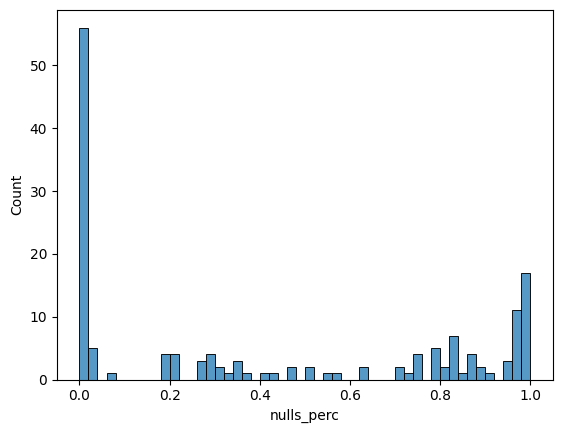

In [11]:
sns.histplot(data=nulls_df, x="nulls_perc", bins=50)

In [12]:
elegible_variables = nulls_df[nulls_df["nulls_perc"] < 0.01]
print(f"Number of elegible variables: {elegible_variables.shape[0]}")
df_aux = df_aux[elegible_variables["variable"]]
print(list(elegible_variables.index))

print(f"Shape of df_aux before dropping NA: {df_aux.shape}")
df_aux = df_aux.dropna(subset=list(elegible_variables.index))
print(f"Shape of df_aux after dropping NA: {df_aux.shape}")

Number of elegible variables: 51
['v147a', 'v163', 'v215a', 'v215bi', 'egp11', 'v217a', 'v217bi', 'v216bi', 'v216a', 't_hogar', 'v155', 'v135', 'aglo', 'v171', 'v156', 'age', 'v154', 'v158', 'v111', 'v142', 'v186', 'v110', 'v139', 'cat_ocup', 'v162', 'v157', 'v118a', 'v141', 'v183ciuo_first_2digits', 'v120', 'v153', 'sex_id', 'c_hogar', 'v183ciuo_last_2digits', 'v117', 'f_calib3', 'v134a', 'region', 'estado', 'nivel_ed', 'v182caes', 'v189', 'v183cno', 'v191', 'v161', 'v164', 'estrato_U', 't_aglo', 'v119', 'public_worker', 'v140']
Shape of df_aux before dropping NA: (9377, 51)
Shape of df_aux after dropping NA: (9166, 51)


In [13]:
variables_df = pd.read_csv("../data/raw/metadata_base_enespersonas.csv")
variables_df = variables_df[variables_df["Column Title"].isin(elegible_variables.index)]
variables_df = variables_df.set_index("Column Title")
print(variables_df)

                               Data Type  \
Column Title                               
f_calib3                         Integer   
region                           Integer   
aglo                             Integer   
t_aglo                           Integer   
estrato_U                        Integer   
v110                             Integer   
v111                             Integer   
c_hogar                          Integer   
t_hogar                          Integer   
v117                             Integer   
v118a                            Integer   
v119                             Integer   
v120                             Integer   
nivel_ed                         Integer   
v134a                            Integer   
v135                             Integer   
v139                             Integer   
v140                             Integer   
v141                             Integer   
v142                             Integer   
v147a                           

variales_df will be used to understand the variables that we have in the dataset and statistics

In [14]:
# distinct values per variable
distinct_values = df_aux.nunique(dropna=False)
variables_df["distinct_values"] = distinct_values
variables_df.sort_values("distinct_values", ascending=False).head(20)

,Data Type,Description,distinct_values
Column Title,,,
f_calib3,Integer,Calibration Factor,2585
v215bi,Integer,Income Amount from Retirements or Pensions Las...,322
v183cno,Text (string),Type of Occupation (National Classifier of Occ...,292
estrato_U,Integer,Stratum of the Primary Unit,268
v217bi,Integer,Other Income Amount Last Month (Imputed),175
v216bi,Integer,"Income Amount from Social Pensions, AHU, or Ot...",138
v182caes,Text (string),Economic Activity Code (CAES Mercosur 1.0),134
v163,Integer,Number of Hours Dedicated to the Mentioned Hou...,80
v183ciuo_last_2digits,Text (string),Type of Occupation (International Standard Cla...,51


In [15]:
variables_df.index

Index(['f_calib3', 'region', 'aglo', 't_aglo', 'estrato_U', 'v110', 'v111',
       'c_hogar', 't_hogar', 'v117', 'v118a', 'v119', 'v120', 'nivel_ed',
       'v134a', 'v135', 'v139', 'v140', 'v141', 'v142', 'v147a', 'v153',
       'v154', 'v155', 'v156', 'v157', 'v158', 'v161', 'v162', 'v163', 'v164',
       'v171', 'estado', 'v186', 'v182caes', 'v183ciuo_first_2digits',
       'v183ciuo_last_2digits', 'v183cno', 'v189', 'v191', 'cat_ocup', 'egp11',
       'v215a', 'v215bi', 'v216a', 'v216bi', 'v217a', 'v217bi'],
      dtype='object', name='Column Title')

<Axes: xlabel='distinct_values', ylabel='Count'>

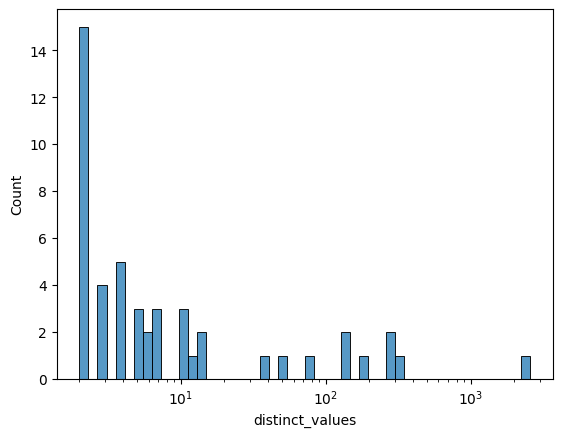

In [16]:
# Histogram of distinct values
sns.histplot(data=variables_df, x="distinct_values", bins=50, log_scale=True)

Quantity of continuous variables: 6


/home/aaron/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/aaron/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/aaron/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


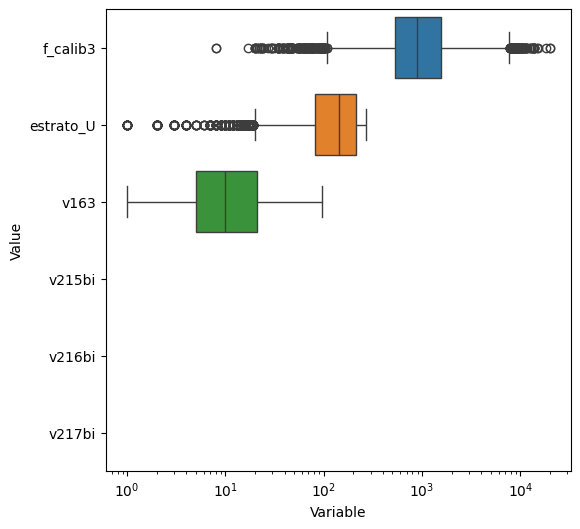

In [17]:
exclude_vars = [
	"v183cno",
	"v183ciuo",
	"v182caes",
	"v183ciuo_first_2digits",
	"v183ciuo_last_2digits",
]
variables_df_cont = variables_df[
	(variables_df["distinct_values"] > 20) & (~variables_df.index.isin(exclude_vars))
]
print(f"Quantity of continuous variables: {len(variables_df_cont)}")
# Boxplot of each continuous variable in the same figure
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_aux[variables_df_cont.index], orient="h", log_scale=True)
plt.xlabel("Variable")
plt.ylabel("Value")
plt.show()

In [18]:
variables_df_disc = variables_df[
	(variables_df["distinct_values"] <= 20) | variables_df.index.isin(exclude_vars)
].copy()

variables_df_disc["distinct_unique_values"] = variables_df_disc.index.map(
	lambda var: df_aux[var].unique().tolist()
)

print(f"Quantity of discrete variables: {len(variables_df_disc)}")

print("Transforming discrete variables to integers...")
for var in variables_df_disc.index:
	df_aux[var] = df_aux[var].astype("int", errors="ignore")

variables_df_disc.sort_values("distinct_values", ascending=False).head(20)

Quantity of discrete variables: 42
Transforming discrete variables to integers...


,Data Type,Description,distinct_values,distinct_unique_values
Column Title,,,,
v183cno,Text (string),Type of Occupation (National Classifier of Occ...,292,"[72203.0, 41312.0, 30314.0, 70313.0, 30313.0, ..."
v182caes,Text (string),Economic Activity Code (CAES Mercosur 1.0),134,"[8401, 8501, 4804, 800, 4803, 9700, 4502, 1100..."
v183ciuo_last_2digits,Text (string),Type of Occupation (International Standard Cla...,51,"[20, 30, 23, 11, 12, 13, 32, 22, 10, 41, 64, 4..."
v183ciuo_first_2digits,Text (string),Type of Occupation (International Standard Cla...,37,"[31, 23, 52, 81, 91, 53, 72, 83, 93, 71, 41, 2..."
t_hogar,Integer,Number of People in the Household,14,"[5.0, 4.0, 6.0, 3.0, 7.0, 2.0, 1.0, 8.0, 9.0, ..."
c_hogar,Integer,Household Composition,13,"[6.0, 8.0, 7.0, 3.0, 4.0, 1.0, 5.0, 2.0, 10.0,..."
v110,Integer,Month of Birth,12,"[2.0, 10.0, 4.0, 6.0, 8.0, 3.0, 9.0, 5.0, 12.0..."
v111,Integer,Relationship to the Household Head (PSH),11,"[1.0, 2.0, 3.0, 5.0, 9.0, 10.0, 6.0, 7.0, 12.0..."
egp11,Integer,"Social Class (EGP CASMISN, Ganzeboom and Treiman)",11,"[1.0, 2.0, 4.0, 8.0, 9.0, 3.0, 11.0, 6.0, 7.0,..."


In [19]:
variables_df_disc.loc["v183ciuo_last_2digits"].to_dict()

{'Data Type': 'Text (string)',
 'Description': 'Type of Occupation (International Standard Classification of Occupations 2008)',
 'distinct_values': 51,
 'distinct_unique_values': [20,
  30,
  23,
  11,
  12,
  13,
  32,
  22,
  10,
  41,
  64,
  43,
  50,
  31,
  56,
  21,
  33,
  52,
  53,
  40,
  45,
  14,
  0,
  59,
  15,
  29,
  62,
  55,
  42,
  16,
  19,
  61,
  26,
  46,
  27,
  51,
  44,
  35,
  34,
  57,
  65,
  17,
  54,
  69,
  24,
  25,
  39,
  49,
  18,
  36,
  66]}

In [20]:
variables_df_disc.index

Index(['region', 'aglo', 't_aglo', 'v110', 'v111', 'c_hogar', 't_hogar',
       'v117', 'v118a', 'v119', 'v120', 'nivel_ed', 'v134a', 'v135', 'v139',
       'v140', 'v141', 'v142', 'v147a', 'v153', 'v154', 'v155', 'v156', 'v157',
       'v158', 'v161', 'v162', 'v164', 'v171', 'estado', 'v186', 'v182caes',
       'v183ciuo_first_2digits', 'v183ciuo_last_2digits', 'v183cno', 'v189',
       'v191', 'cat_ocup', 'egp11', 'v215a', 'v216a', 'v217a'],
      dtype='object', name='Column Title')

In [21]:
variables_df_cont.index

Index(['f_calib3', 'estrato_U', 'v163', 'v215bi', 'v216bi', 'v217bi'], dtype='object', name='Column Title')

In [22]:
df_aux_log = df_aux.copy()
for var in variables_df_cont.index:
	df_aux_log[var] = np.log1p(df_aux_log[var])
	print(f"Transformed {var} to log scale")

Transformed f_calib3 to log scale
Transformed estrato_U to log scale
Transformed v163 to log scale
Transformed v215bi to log scale
Transformed v216bi to log scale
Transformed v217bi to log scale


In [23]:
df_aux_log["v183ciuo_first_2digits"].value_counts()

v183ciuo_first_2digits
91    1525
52    1408
23     906
71     692
83     642
41     466
51     437
53     430
93     347
54     340
72     239
92     229
32     211
13     137
43     130
33     124
31     122
22     117
61     102
26      72
94      68
24      60
21      56
34      51
95      45
75      38
35      29
25      27
96      24
81      23
44      23
42      13
14      11
74       9
62       8
11       3
73       2
Name: count, dtype: int64

In [24]:
ciuo_possible_combinations_df = df_aux_log[
	["v183ciuo_first_2digits", "v183ciuo_last_2digits"]
].drop_duplicates()
print(ciuo_possible_combinations_df.shape)
ciuo_possible_combinations_df.head()

(296, 2)


,v183ciuo_first_2digits,v183ciuo_last_2digits
0,31,20
1,23,30
2,52,23
3,81,11
5,91,12


In [25]:
ciuo_possible_combinations_df["v183ciuo_first_2digits"].value_counts()

v183ciuo_first_2digits
33    24
31    20
71    15
23    15
26    15
32    14
52    14
51    13
13    12
22    11
34    11
83    10
61    10
21    10
72     9
93     8
91     7
24     7
92     7
42     7
35     6
53     6
54     5
43     5
96     5
75     4
14     4
41     4
74     3
62     3
81     3
94     2
25     2
73     2
11     1
44     1
95     1
Name: count, dtype: int64

Case when the first 2 digits is 33 (v183ciuo_first_2digits)

In [26]:
df_aux_log_91 = df_aux_log[df_aux_log["v183ciuo_first_2digits"] == 91]
variables_df_disc.drop("v183ciuo_first_2digits", inplace=True)
print(df_aux_log_91.shape)
df_aux_log_91.head()

(1525, 51)


,v147a,v163,v215a,v215bi,egp11,v217a,v217bi,v216bi,v216a,t_hogar,...,v189,v183cno,v191,v161,v164,estrato_U,t_aglo,v119,public_worker,v140
5,6,2.564949,0,0.000000,9,0,0.0,0.000000,0,4,...,5,56314,3,1,1,5.105945,4,1,1,2
15,4,3.044522,0,0.000000,9,0,0.0,7.601402,1,5,...,3,56314,3,1,1,5.105945,4,1,1,3
28,6,3.367296,0,0.000000,9,0,0.0,0.000000,0,3,...,2,56314,3,2,1,5.049856,1,3,1,1
38,6,0.000000,1,7.783641,9,0,0.0,0.000000,0,3,...,2,56314,3,2,0,5.049856,1,1,2,5
42,6,2.397895,0,0.000000,9,0,0.0,0.000000,0,2,...,1,55314,3,1,0,5.257495,3,1,2,4


In [27]:
import statsmodels.formula.api as smf
import pandas as pd

# Fit the model using R-style formulas
target = "v183ciuo_last_2digits"
predictors_disc = " + ".join(
	{f"C({var})" for var in set(variables_df_disc.index) - {target}}
)
print("Target:", target)
print("Disc predictors:", predictors_disc)
predictors_cont = " + ".join(set(variables_df_cont.index) - {target})
print("Cont predictors:", predictors_cont)

Target: v183ciuo_last_2digits
Disc predictors: C(cat_ocup) + C(v141) + C(v191) + C(v120) + C(c_hogar) + C(v217a) + C(v189) + C(v182caes) + C(v171) + C(v119) + C(v139) + C(estado) + C(egp11) + C(v156) + C(aglo) + C(v157) + C(v215a) + C(v110) + C(v142) + C(v154) + C(v161) + C(v140) + C(v183cno) + C(v153) + C(v134a) + C(v118a) + C(v155) + C(nivel_ed) + C(v111) + C(v164) + C(v158) + C(v147a) + C(v135) + C(v117) + C(v186) + C(t_aglo) + C(t_hogar) + C(v216a) + C(v162) + C(region)
Cont predictors: f_calib3 + v163 + v217bi + v216bi + estrato_U + v215bi


In [28]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

feature_cols = list(
	(set(variables_df_disc.index) | set(variables_df_cont.index)) - {target}
)
X = df_aux_log_91[feature_cols].astype(float)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
	scaler.fit_transform(X), columns=X.columns, index=df_aux_log_91.index
)
X_scaled = sm.add_constant(X_scaled, has_constant="add")
y = df_aux_log_91[target]

model_l1 = sm.MNLogit(y, X_scaled)
result_l1 = model_l1.fit_regularized(method="l1", alpha=0.5, maxiter=500, disp=False)
print("\nL1-regularized fit (stable baseline):")
print(result_l1.summary())

/home/aaron/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 282 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/home/aaron/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
/home/aaron/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



L1-regularized fit (stable baseline):
                            MNLogit Regression Results                           
Dep. Variable:     v183ciuo_last_2digits   No. Observations:                 1525
Model:                           MNLogit   Df Residuals:                     1243
Method:                              MLE   Df Model:                          276
Date:                   Mon, 27 Apr 2026   Pseudo R-squ.:                  0.8791
Time:                           04:13:36   Log-Likelihood:                -131.88
converged:                         False   LL-Null:                       -1090.5
Covariance Type:               nonrobust   LLR p-value:                3.447e-243
v183ciuo_last_2digits=11       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        6.7982      1.621      4.194      0.000       3.621       9.975
v111                     -

In [29]:
# Variable Importance Analysis from MNLogit Model
import pandas as pd
import numpy as np

# Extract coefficients - result_l1.params has shape (n_features, n_classes)
# where rows = feature names, columns = outcome classes
coef_df = result_l1.params.copy()

print(f"Coefficient matrix shape: {coef_df.shape}")
print(f"Coefficient index (feature names, first 10): {coef_df.index.tolist()[:10]}")
print(f"Coefficient columns (outcome classes): {coef_df.columns.tolist()}")

# Drop 'const' if present
if "const" in coef_df.index:
	coef_df = coef_df.drop("const")
	print(f"Dropped intercept. New shape: {coef_df.shape}")

# Compute importance metrics
importance_metrics = pd.DataFrame(index=coef_df.index)

# 1. Mean absolute coefficient (average impact across all classes)
importance_metrics["mean_abs_coef"] = coef_df.abs().mean(axis=1)

# 2. Max absolute coefficient (strongest single-class effect)
importance_metrics["max_abs_coef"] = coef_df.abs().max(axis=1)

# 3. Count of non-zero (or near-zero) coefficients across classes
importance_metrics["n_nonzero"] = (coef_df.abs() > 1e-6).sum(axis=1)

# 4. Standard deviation of coefficients across classes (stability)
importance_metrics["std_coef"] = coef_df.std(axis=1)

# 5. Coefficient range (max - min)
importance_metrics["range_coef"] = coef_df.max(axis=1) - coef_df.min(axis=1)

# Compute overall importance score (weighted combination)
max_mean = importance_metrics["mean_abs_coef"].max()
max_max = importance_metrics["max_abs_coef"].max()
max_nz = importance_metrics["n_nonzero"].max()
max_std = importance_metrics["std_coef"].max()

importance_metrics["importance_score"] = (
	0.4 * (importance_metrics["mean_abs_coef"] / max_mean if max_mean > 0 else 0)
	+ 0.3 * (importance_metrics["max_abs_coef"] / max_max if max_max > 0 else 0)
	+ 0.2 * (importance_metrics["n_nonzero"] / max_nz if max_nz > 0 else 0)
	+ 0.1 * (importance_metrics["std_coef"] / max_std if max_std > 0 else 0)
)

# Sort by importance score
importance_sorted = importance_metrics.sort_values("importance_score", ascending=False)

print("\n" + "=" * 100)
print("VARIABLE IMPORTANCE RANKING (from MNLogit Model)")
print("=" * 100)
print(f"\nTotal non-constant features: {len(importance_sorted)}")
print("\nTop 20 Most Influential Variables:")
print(
	importance_sorted[
		["mean_abs_coef", "max_abs_coef", "n_nonzero", "importance_score"]
	]
	.head(20)
	.to_string()
)

print("\n" + "=" * 100)
print("INTERPRETATION GUIDE:")
print("=" * 100)
print(
	"• mean_abs_coef: Average absolute coefficient magnitude across all outcome classes"
)
print("• max_abs_coef: Strongest single-class effect")
print("• n_nonzero: Number of outcome classes where variable has non-zero coefficient")
print(
	"• importance_score: Composite ranking (40% mean + 30% max + 20% activity + 10% stability)"
)

Coefficient matrix shape: (47, 6)
Coefficient index (feature names, first 10): ['const', 'v111', 'v117', 'v142', 'v163', 'v110', 'v216a', 'v155', 'v139', 'cat_ocup']
Coefficient columns (outcome classes): [0, 1, 2, 3, 4, 5]
Dropped intercept. New shape: (46, 6)

VARIABLE IMPORTANCE RANKING (from MNLogit Model)

Total non-constant features: 46

Top 20 Most Influential Variables:
           mean_abs_coef  max_abs_coef  n_nonzero  importance_score
v183cno         0.886744      2.655662          4          0.933333
v182caes        0.758790      1.515274          6          0.784794
v164            0.750759      1.606385          5          0.760703
v162            0.462405      0.918464          6          0.551282
v189            0.474132      1.114935          4          0.523108
c_hogar         0.424671      0.919294          5          0.499994
v171            0.444930      1.100120          4          0.490151
v118a           0.292416      1.275329          4          0.445123
v217bi 

Top 15 variables available: 15


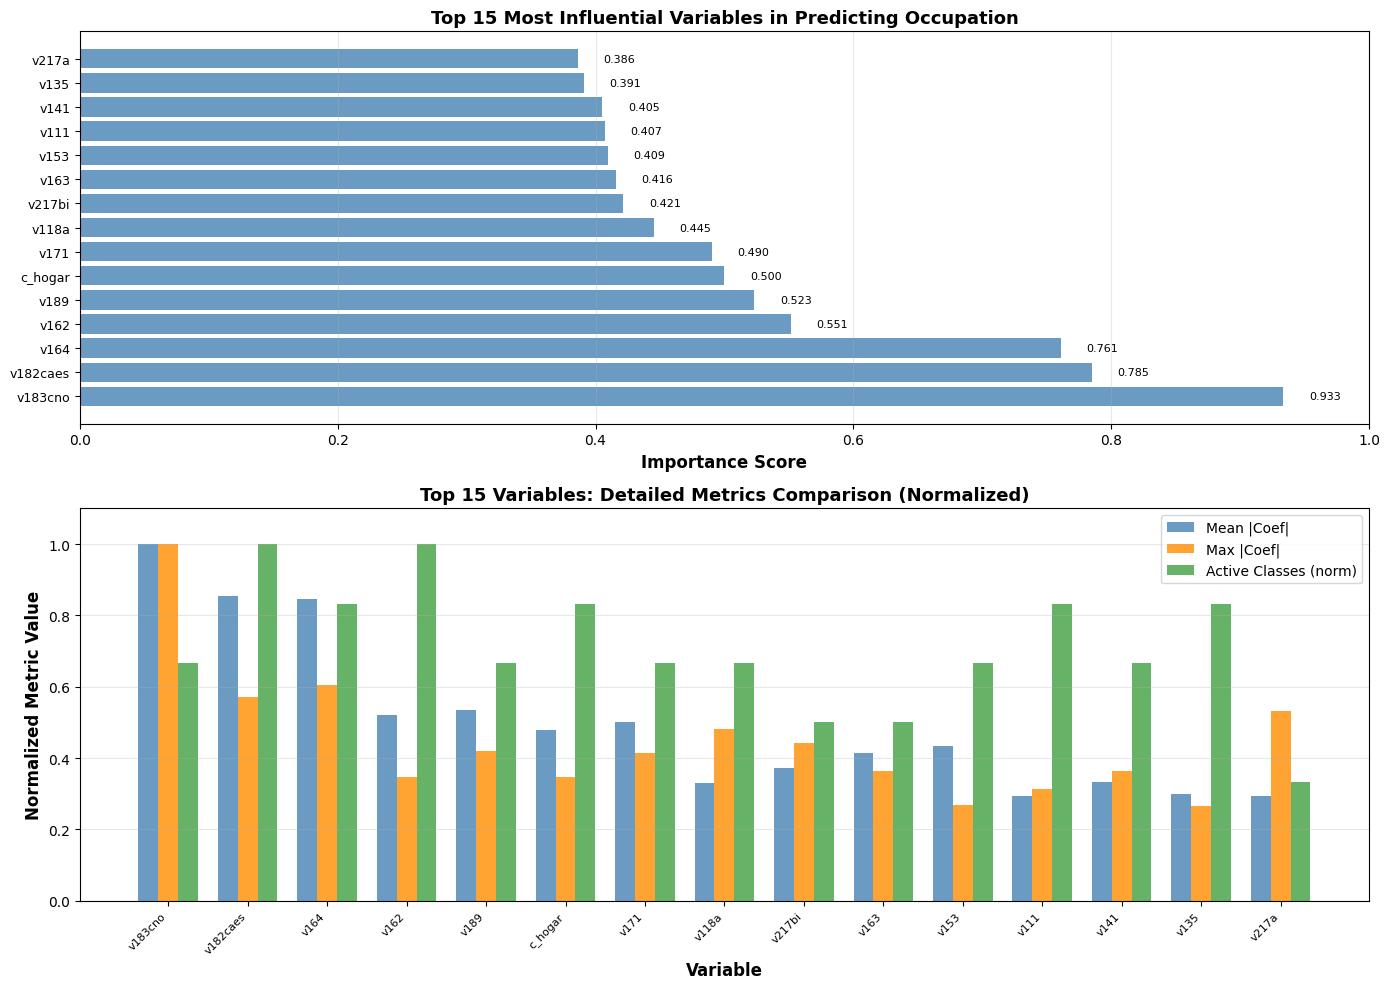


DETAILED METRICS FOR TOP 15 VARIABLES (Excluding Intercept)
          Mean Coef  Max Coef  Active Classes  Importance
v183cno    0.886744  2.655662               4    0.933333
v182caes   0.758790  1.515274               6    0.784794
v164       0.750759  1.606385               5    0.760703
v162       0.462405  0.918464               6    0.551282
v189       0.474132  1.114935               4    0.523108
c_hogar    0.424671  0.919294               5    0.499994
v171       0.444930  1.100120               4    0.490151
v118a      0.292416  1.275329               4    0.445123
v217bi     0.330816  1.171222               3    0.421342
v163       0.368613  0.965332               3    0.415783
v153       0.385166  0.710339               4    0.409379
v111       0.260233  0.836091               5    0.407331
v141       0.295559  0.966479               4    0.405019
v135       0.264282  0.706888               5    0.390729
v217a      0.260425  1.412062               2    0.386099


In [30]:
# Create improved visualizations for variable importance
import matplotlib.pyplot as plt
import numpy as np

# Remove 'const' if it exists for cleaner visualization
if "const" in importance_sorted.index:
	importance_sorted_no_const = importance_sorted.drop("const")
else:
	importance_sorted_no_const = importance_sorted.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Use version without 'const' for cleaner visualization
top_n = 15
top_vars = importance_sorted_no_const.head(top_n)

print(f"Top {top_n} variables available: {len(top_vars)}")

# Plot 1: Top N Variables by Importance Score
scores = top_vars["importance_score"].values
var_names = top_vars.index.tolist()

bars = axes[0].barh(range(len(var_names)), scores, color="steelblue", alpha=0.8)
axes[0].set_yticks(range(len(var_names)))
axes[0].set_yticklabels(var_names, fontsize=9)
axes[0].set_xlabel("Importance Score", fontsize=12, fontweight="bold")
axes[0].set_title(
	f"Top {len(var_names)} Most Influential Variables in Predicting Occupation",
	fontsize=13,
	fontweight="bold",
)
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", alpha=0.3)

# Add value labels on bars
for i, (score, bar) in enumerate(zip(scores, bars)):
	axes[0].text(score + 0.02, i, f"{score:.3f}", va="center", fontsize=8)

# Plot 2: Detailed Metrics Comparison for Top N
top_variables = importance_sorted_no_const.head(top_n)
x_pos = np.arange(len(top_variables))
width = 0.25

# Normalize metrics for comparison
mean_coef_norm = top_variables["mean_abs_coef"] / top_variables["mean_abs_coef"].max()
max_coef_norm = top_variables["max_abs_coef"] / top_variables["max_abs_coef"].max()
n_nonzero_norm = top_variables["n_nonzero"] / top_variables["n_nonzero"].max()

bars1 = axes[1].bar(
	x_pos - width,
	mean_coef_norm.values,
	width,
	label="Mean |Coef|",
	color="steelblue",
	alpha=0.8,
)
bars2 = axes[1].bar(
	x_pos,
	max_coef_norm.values,
	width,
	label="Max |Coef|",
	color="darkorange",
	alpha=0.8,
)
bars3 = axes[1].bar(
	x_pos + width,
	n_nonzero_norm.values,
	width,
	label="Active Classes (norm)",
	color="green",
	alpha=0.6,
)

axes[1].set_xlabel("Variable", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Normalized Metric Value", fontsize=12, fontweight="bold")
axes[1].set_title(
	f"Top {len(top_variables)} Variables: Detailed Metrics Comparison (Normalized)",
	fontsize=13,
	fontweight="bold",
)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top_variables.index, fontsize=8, rotation=45, ha="right")
axes[1].legend(loc="upper right", fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed metrics table
print("\n" + "=" * 100)
print(f"DETAILED METRICS FOR TOP {len(top_variables)} VARIABLES (Excluding Intercept)")
print("=" * 100)
detail_table = importance_sorted_no_const[
	["mean_abs_coef", "max_abs_coef", "n_nonzero", "importance_score"]
].head(top_n)
detail_table.columns = ["Mean Coef", "Max Coef", "Active Classes", "Importance"]
print(detail_table.to_string())

In [1]:
from typing import Any
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

In [2]:
enes_ciuo_path="../data/graphs/enes_all/caes/projection_hidalgo.gexf"
eph_cno_path="../data/graphs/eph/Usu_individual_T319/caes/projection_hidalgo.gexf"

In [3]:
graph_caes_ciuo = nx.read_gexf(enes_ciuo_path, node_type=int)
graph_caes_cno = nx.read_gexf(eph_cno_path, node_type=int)

edges_caes_ciuo_init = graph_caes_ciuo.edges(data=True)
edges_caes_cno_init = graph_caes_cno.edges(data=True)

nodes = set(graph_caes_ciuo.nodes()) | set(graph_caes_cno.nodes())

print(f"Number of nodes in CAES-CIUO: {len(graph_caes_ciuo.nodes())}")
print(f"Number of nodes in CAES-CNO: {len(graph_caes_cno.nodes())}")
print(f"Number of edges in CAES-CIUO: {len(edges_caes_ciuo_init)}")
print(f"Number of edges in CAES-CNO: {len(edges_caes_cno_init)}")
print(f"Number of nodes in union: {len(nodes)}")

Number of nodes in CAES-CIUO: 143
Number of nodes in CAES-CNO: 141
Number of edges in CAES-CIUO: 7185
Number of edges in CAES-CNO: 7604
Number of nodes in union: 152


In [4]:
# Extrat weight from dict
edges_caes_ciuo = [(u, v, d["weight"]) for u, v, d in edges_caes_ciuo_init]
edges_caes_ciuo.extend([(v, u, d["weight"]) for u, v, d in edges_caes_ciuo_init])

edges_caes_cno = [(u, v, d["weight"]) for u, v, d in edges_caes_cno_init]
edges_caes_cno.extend([(v, u, d["weight"]) for u, v, d in edges_caes_cno_init])

In [5]:
edges_df_ciuo = pd.DataFrame(edges_caes_ciuo, columns=["source", "target", "weight"])
edges_df_ciuo["graph"] = "CAES-CIUO"
edges_df_cno = pd.DataFrame(edges_caes_cno, columns=["source", "target", "weight"])
edges_df_cno["graph"] = "CAES-CNO"
edges_df = pd.concat([edges_df_ciuo, edges_df_cno], ignore_index=True)

In [6]:
edges_df_ciuo

,source,target,weight,graph
0,100,8501,0.000018,CAES-CIUO
1,100,102,0.008745,CAES-CIUO
2,100,200,0.047655,CAES-CIUO
3,100,3200,0.000181,CAES-CIUO
4,100,4904,0.000015,CAES-CIUO
...,...,...,...,...
14365,9700,9602,0.000655,CAES-CIUO
14366,9603,9602,0.000523,CAES-CIUO
14367,9609,9603,0.011178,CAES-CIUO
14368,9700,9603,0.000015,CAES-CIUO


In [7]:
print(edges_df.shape)
edges_df = edges_df.dropna(subset=["weight"])
edges_df["weight"] = edges_df["weight"].astype(float)
edges_df = edges_df.drop_duplicates(subset=["source", "target", "graph"])
print(edges_df.shape)
edges_df.head()

(29578, 4)
(29578, 4)


,source,target,weight,graph
0,100,8501,0.000018,CAES-CIUO
1,100,102,0.008745,CAES-CIUO
2,100,200,0.047655,CAES-CIUO
3,100,3200,0.000181,CAES-CIUO
4,100,4904,0.000015,CAES-CIUO


In [8]:
fig = px.scatter_3d(
    edges_df,
    x='source',
    y='target',
    z='weight',
    color='graph',
    size='weight',
    size_max=15,
    title="Comparison of CAES-CIUO and CAES-CNO Projections",
	width=1000,
	height=1000,
)

fig.show()